In [1]:
import os
import pandas as pd
pd.options.future.infer_string = False

import pypsa
import xarray as xr

E0000 00:00:1774450417.658265 182582134 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1774450417.658311 182582134 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1774450417.658323 182582134 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1774450417.658324 182582134 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1774450417.658327 182582134 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


# Prepare data

## Read input time-series

In [2]:
input_fl = "data/bw_microgrid_inputs.csv"

In [3]:
inputs_df = pd.read_csv(input_fl, index_col=0)

In [4]:
inputs_df.head(2)

,load,solar,runoff
time,,,
2021-03-01 07:00:00,7.751905,34.314,35.337681
2021-03-01 08:00:00,8.097902,52.144,35.433885


<Axes: xlabel='time'>

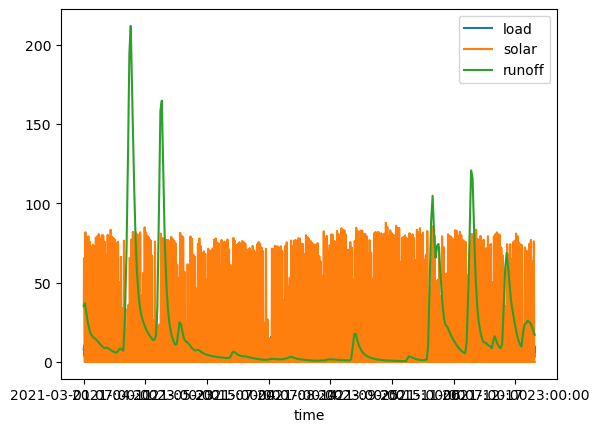

In [5]:
inputs_df.plot()

# Build network model

In [6]:
# solar-rooftop,2030,investment,725,EUR/kWel,ETIP PV,,2013
# hydro,2030,investment,2000,EUR/kWel,DIW DataDoc http://hdl.handle.net/10419/80348,,2013

solar_capital_cost = 900
hydro_capital_cost = 3_600

diesel_capital_cost = 600
fuel_cost = 0.05

k_scale_hydro = 10

In [7]:
def build_green_microgrid(
        df
    ):
    """
    Optimise a model with considering hydro and solar only
    """
    network = pypsa.Network(snapshots = df.index)
    network.add("Bus", "B1")

    network.add("Generator", "PV",
                carrier = "solar",
                bus="B1",
                capital_cost = solar_capital_cost,
                #p_nom_max = 600_000,
                p_max_pu = df["solar"],
                p_nom_extendable = True,
                )

    # a fake generator which represents unserved energy 
    network.add("Generator", "LoadShedding",
                carrier = "shedding",
                bus="B1",
                capital_cost = 0,
                marginal_cost = 100_000,
                p_nom_extendable = True)

    network.add("StorageUnit", "Hydro",
                bus="B1",
                carrier="hydro",
                max_hours = 5,
                p_max_pu=1.0,  # dispatch
                p_min_pu=0.0,  # store
                p_nom_max = hydro_capital_cost,
                inflow = df["runoff"] / k_scale_hydro,       
                p_nom_extendable = True,
                efficiency_dispatch=0.9,
                efficiency_store=0.0,
                cyclic_state_of_charge=True)

    network.add("Load", "L1",
                bus="B1",
                carrier="el_demand",                
                p_set=df["load"])
    return network

In [8]:
def build_microgrid(
        df
    ):
    """
    Optimise a model with considering hydro, solar and diesel
    """
    network = pypsa.Network(snapshots = df.index)
    network.add("Bus", "B1")

    network.add("Generator", "PV",
                carrier = "solar",
                bus="B1",
                capital_cost = solar_capital_cost,
                #p_nom_max = 600_000,
                p_max_pu = df["solar"],
                p_nom_extendable = True,
                )

    # a fake generator which represents unserved energy 
    network.add("Generator", "LoadShedding",
                carrier = "shedding",
                bus="B1",
                capital_cost = 0,
                marginal_cost = 100_000,
                p_nom_extendable = True)

    network.add("StorageUnit", "Hydro",
                bus="B1",
                carrier="hydro",
                max_hours = 2,
                p_max_pu=1.0,  # dispatch
                p_min_pu=0.0,  # store
                p_nom_max = hydro_capital_cost,
                inflow = df["runoff"] / k_scale_hydro,       
                p_nom_extendable = True,
                efficiency_dispatch=0.9,
                efficiency_store=0.0,
                cyclic_state_of_charge=True)
    
    network.add("Generator", "diesel",
                carrier = "diesel",
                bus="B1",
                capital_cost = diesel_capital_cost,
                operational_cost = fuel_cost,
                p_nom_extendable = True,
                )    

    network.add("Load", "L1",
                bus="B1",
                carrier="el_demand",                
                p_set=df["load"])
    return network

### Energy modelling

In [9]:
green_microgrid = build_green_microgrid(df=inputs_df)
microgrid = build_microgrid(df=inputs_df)

In [10]:
green_microgrid.sanitize()
microgrid.sanitize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 5 missing carriers: ['AC', 'el_demand', 'hydro', 'shedding', 'solar']
INFO:pypsa.components._types.carriers:Assigned colors to 5 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 6 missing carriers: ['AC', 'diesel', 'el_demand', 'hydro', 'shedding', 'solar']
INFO:pypsa.components._types.carriers:Assigned colors to 6 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.


In [11]:
green_microgrid.optimize()
microgrid.optimize()

/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_41418/716645955.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  green_microgrid.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 503.53it/s]
INFO:linopy.io: Writing time: 0.11s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-8aze6ph1 has 87772 rows; 43887 cols; 157217 nonzeros
Coefficient ranges:
  Matrix  [5e-03, 9e+01]
  Cost    [9e+02, 1e+05]
  Bound   [5e-02, 2e+01]
  RHS     [8e-03, 4e+03]
Presolving model
14348 rows, 28757 cols, 46621 nonzeros  0s
Dependent equations search running on 10616 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
14133 rows, 28327 cols, 45976 nonzeros  0s
Presolve reductions: rows 14133(-73639); columns 28327(-15560); nonzeros 45976(-111241) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43887 primals, 87772 duals
Objective: 7.29e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      10744     7.2931315658e+08 Pr: 0(0) 2.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-8aze6ph1
Model status        : Optimal
Simplex   iterations: 10744
Objective value     :  7.2931315658e+08
P-D objective error :  3.1873566570e-15
HiGHS run time      :          2.02


/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_41418/716645955.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  microgrid.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 512.94it/s]
INFO:linopy.io: Writing time: 0.08s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-fy0bhhbd has 102401 rows; 51202 cols; 186474 nonzeros
Coefficient ranges:
  Matrix  [5e-03, 9e+01]
  Cost    [6e+02, 1e+05]
  Bound   [5e-02, 2e+01]
  RHS     [8e-03, 4e+03]
Presolving model
25019 rows, 39429 cols, 75057 nonzeros  0s
Dependent equations search running on 14195 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
24806 rows, 39003 cols, 74418 nonzeros  0s
Presolve reductions: rows 24806(-77595); columns 39003(-12199); nonzeros 74418(-112056) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 14195(34928.2) 0.2s
      19035     1.9624480278e+03 Pr: 750(433.692) 5.3s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 51202 primals, 102401 duals
Objective: 1.73e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      19636     1.7343306038e+03 Pr: 0(0) 6.1s
      19636     1.7343306038e+03 Pr: 0(0) 6.1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-fy0bhhbd
Model status        : Optimal
Simplex   iterations: 19636
Objective value     :  1.7343306038e+03
P-D objective error :  1.6186392410e-14
HiGHS run time      :          6.11


('ok', 'optimal')

#### Statitics

In [12]:
green_microgrid.statistics()

Optimal Capacity  Installed Capacity       Supply  \
Generator   shedding           17.28782                 0.0   7287.99342   
            solar             570.90554                 0.0  19031.38980   
Load        el_demand           0.00000                 0.0      0.00000   
StorageUnit hydro            3600.00000                 0.0  11642.10828   

                       Withdrawal  Energy Balance Transmission  \
Generator   shedding       0.0000      7287.99342          0.0   
            solar          0.0000     19031.38980          0.0   
Load        el_demand  37961.4915    -37961.49150          0.0   
StorageUnit hydro          0.0000     11642.10828          0.0   

                       Capacity Factor   Curtailment  Capital Expenditure  \
Generator   shedding          0.057638  1.191551e+05              0.00000   
            solar             0.004558  8.768820e+07         513814.98346   
Load        el_demand              NaN  0.000000e+00              0.00000   
StorageUnit hydro             0.000442  2.631876e+07              0.00000   

                       Operational Expenditure       Revenue   Market Value  
Generator   shedding              7.287993e+08  7.287993e+08  100000.428867  
            solar                 0.000000e+00  5.138150e+05      26.998286  
Load        el_demand             0.000000e+00 -1.893524e+09            NaN  
StorageUnit hydro                 0.000000e+00  1.164211e+09   99999.790772

In [13]:
microgrid.statistics()

Optimal Capacity  Installed Capacity       Supply  \
Generator   diesel              2.58084                 0.0  11156.87241   
            solar               0.20647                 0.0  15162.51081   
Load        el_demand           0.00000                 0.0      0.00000   
StorageUnit hydro            3600.00000                 0.0  11642.10828   

                       Withdrawal  Energy Balance Transmission  \
Generator   diesel         0.0000     11156.87241          0.0   
            solar          0.0000     15162.51081          0.0   
Load        el_demand  37961.4915    -37961.49150          0.0   
StorageUnit hydro          0.0000     11642.10828          0.0   

                       Capacity Factor   Curtailment  Capital Expenditure  \
Generator   diesel            0.591052  7.719423e+03           1548.50658   
            solar            10.040587  1.655729e+04            185.82402   
Load        el_demand              NaN  0.000000e+00              0.00000   
StorageUnit hydro             0.000442  2.631876e+07              0.00000   

                       Operational Expenditure     Revenue  Market Value  
Generator   diesel                         0.0  1548.50658      0.138795  
            solar                          0.0   185.82402      0.012257  
Load        el_demand                      0.0 -3657.76926           NaN  
StorageUnit hydro                          0.0  1923.43866      0.165213

#### Energy balance

In [14]:
green_microgrid.statistics.energy_balance()

component    carrier    bus_carrier
Generator    shedding   AC              7287.99342
             solar      AC             19031.38980
Load         el_demand  AC            -37961.49150
StorageUnit  hydro      AC             11642.10828
dtype: float64

In [15]:
microgrid.statistics.energy_balance()

component    carrier    bus_carrier
Generator    diesel     AC             11156.87241
             solar      AC             15162.51081
Load         el_demand  AC            -37961.49150
StorageUnit  hydro      AC             11642.10828
dtype: float64

#### Dispatch plots

(<Figure size 726.5x300 with 1 Axes>,
 <Axes: xlabel='snapshot', ylabel='Energy Balance'>,
 <seaborn.axisgrid.FacetGrid at 0x17a325a90>)

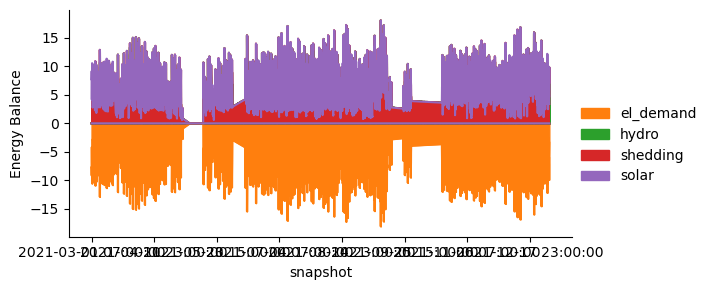

In [16]:
green_microgrid.statistics.energy_balance.plot()

(<Figure size 726.5x300 with 1 Axes>,
 <Axes: xlabel='snapshot', ylabel='Energy Balance'>,
 <seaborn.axisgrid.FacetGrid at 0x31914c410>)

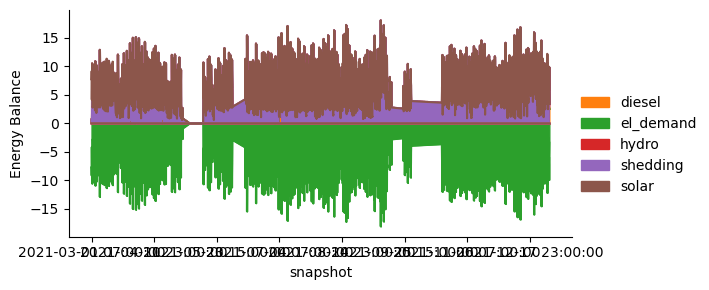

In [17]:
microgrid.statistics.energy_balance.plot()